# Lesson 5: Basic Tube Analysis

Lessons 1-4 analyzed **one complex at a time**: given a fixed set of strands
forming a single complex, what structure(s) does it adopt, and how good is a
target structure? But real experiments mix multiple strand species together
at specific concentrations, and the strands themselves decide - via
equilibrium - how they pair up. This notebook introduces NUPACK's **test
tube** model, `Tube` and `tube_analysis`, which answers: *given these strands
at these concentrations, what complexes form, and at what concentrations?*

**By the end of this notebook you will be able to:**

- Build a `Tube` from a dictionary of strands and initial concentrations,
  using `SetSpec` to control which complexes are considered.
- Run `tube_analysis` and read off equilibrium **complex concentrations**.
- Compute **yield** - the fraction of a target complex formed relative to the
  amount of starting material available.
- Explain why a slight stoichiometric imbalance, or an unintended competing
  strand, changes equilibrium concentrations.

**Prerequisites:** [`02_structural_analysis.ipynb`](02_structural_analysis.ipynb)
(multi-strand complexes, dot-parens-plus notation).


## Introduction

In lesson 2 we built a single `Complex([strand_a, strand_b])` and asked about
*its* structure - implicitly assuming `a` and `b` are entirely bound to each
other. But if you mix 1 $\mu$M of `a` with 1 $\mu$M of `b` in a tube, some
molecules end up as the `a+b` duplex, some as free `a`, some as free `b`,
and (in principle) some as `a+a` or `b+b` homodimers - all simultaneously
present, with concentrations determined by the relative stability of each
species (via its partition function from lessons 1-4) and by mass
conservation (you can't have more bound `a` than there is total `a`).

A `Tube` specifies:

1. **which strands** are present and at **what total concentration** each
   (e.g. `{a: 1e-6, b: 1e-6}`, in molar units),
2. **which complexes** to consider forming, via a `SetSpec` (e.g. "all
   complexes with up to 2 strands").

`tube_analysis` then solves for the equilibrium concentration of every
complex in that set - the tube-level analog of the partition function.

### Roadmap

1. Analyze a simple two-strand tube at equal concentrations, and define
   **yield**.
2. Repeat with an unequal (sub-stoichiometric) mixture and see how yield
   depends on the limiting strand.
3. Add a third, competing strand and see how an unintended interaction
   redistributes concentrations - a preview of the "orthogonality" theme in
   lessons 9-10.


## Setup


In [1]:
from nupack import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

model = Model(material="rna", celsius=37, sodium=1.0)


## Theory: from one complex to a tube of complexes

**`SetSpec`** controls which complexes `tube_analysis` considers - by default
`SetSpec(max_size=1)` (each strand alone). `SetSpec(max_size=2)` adds every
complex formed from at most 2 strands (in any combination, including a strand
with itself), `max_size=3` adds 3-strand complexes, and so on. The number of
possible complexes grows quickly with `max_size` and the number of distinct
strands, so in practice you only go as high as the chemistry you actually
care about.

**Equilibrium concentrations.** For each complex $c$ in the set, NUPACK
already knows $Q_c$ (the partition function, lessons 1-4), which gives its
free energy $\Delta G_c^{\circ} = -RT \ln Q_c$. Combined with the **total
concentration** of each strand (mass conservation: the total amount of strand
`a`, summed over every complex containing `a` weighted by its copy number,
must equal the specified initial concentration), this is enough to solve for
every complex's equilibrium concentration - conceptually the same kind of
calculation as solving for equilibrium concentrations in a system of coupled
binding reactions, just generalized to arbitrarily many species and
complexes at once.

**Yield.** For a target complex (e.g. the `a+b` duplex), a natural measure of
how well the reaction "worked" is

$$
\text{yield} = \frac{[\text{target complex}]}{\min(\text{available limiting strand(s)})}.
$$

A yield near 1 means nearly all of the limiting strand ended up in the target
complex; a low yield means most of it is tied up elsewhere (as monomer, in a
homodimer, or bound to an unintended partner).


## Worked example 1: a simple duplex at equal concentrations

We reuse the `a`/`b` duplex from lesson 2 (`a = GGGAAACCC`, `b = GGGUUUCCC`,
perfectly complementary), each at 1 $\mu$M. `SetSpec(max_size=2)` includes the
monomers `(a)`, `(b)`, the target duplex `(a+b)`, and both possible
homodimers `(a+a)`, `(b+b)`.


In [2]:
a = Strand("GGGAAACCC", name="a")
b = Strand("GGGUUUCCC", name="b")


def find_conc(conc_dict, *strands):
    '''Look up the equilibrium concentration of the complex containing exactly these strands.'''
    names = sorted(s.name for s in strands)
    for cx, val in conc_dict.items():
        if sorted(s.name for s in cx.strands) == names:
            return val
    return 0.0


tube_equal = Tube(
    strands={a: 1e-6, b: 1e-6},
    complexes=SetSpec(max_size=2),
    name="equal",
)

result_equal = tube_analysis(tubes=[tube_equal], model=model, compute=["pfunc"])
conc_equal = result_equal[tube_equal].complex_concentrations

conc_df = pd.DataFrame(
    {"concentration (M)": {str(cx): val for cx, val in conc_equal.items()}}
).sort_values("concentration (M)", ascending=False)
display(conc_df)


,concentration (M)
<Complex (a+b)>,9.596416e-07
<Complex (a)>,4.035765e-08
<Complex (b)>,4.035639e-08
<Complex (b+b)>,1.017735e-12
<Complex (a+a)>,3.881648e-13


In [3]:
yield_equal = find_conc(conc_equal, a, b) / min(1e-6, 1e-6)
print(f"yield of (a+b): {yield_equal:.4f}")


yield of (a+b): 0.9596


**Interpretation.** Almost all of `a` and `b` end up in the `(a+b)` duplex
(yield $\approx 0.96$); each monomer's leftover concentration is about
$4 \times 10^{-8}$ M (4% of the 1 $\mu$M total), and the homodimers
`(a+a)`/`(b+b)` are essentially absent ($\sim 10^{-13}$ M) - consistent with
the duplex's very favorable free energy ($\Delta G^{\circ} \approx -18$
kcal/mol from lesson 2) compared to the homodimers ($\approx -9.2$
kcal/mol each, from a single G-C-rich self-structure rather than a full
9-bp duplex).


## Worked example 1b: an unequal mixture

Now suppose `b` is the limiting reagent: 1 $\mu$M of `a` but only 0.3 $\mu$M
of `b`.


In [4]:
tube_blimited = Tube(
    strands={a: 1e-6, b: 0.3e-6},
    complexes=SetSpec(max_size=2),
    name="b_limited",
)

result_blimited = tube_analysis(tubes=[tube_blimited], model=model, compute=["pfunc"])
conc_blimited = result_blimited[tube_blimited].complex_concentrations

ab_conc = find_conc(conc_blimited, a, b)
yield_vs_b = ab_conc / min(1e-6, 0.3e-6)
yield_vs_a = ab_conc / 1e-6

print(f"[(a+b)] = {ab_conc:.4e} M")
print(f"yield relative to limiting strand b: {yield_vs_b:.4f}")
print(f"yield relative to a:                 {yield_vs_a:.4f}")


[(a+b)] = 2.9927e-07 M
yield relative to limiting strand b: 0.9976
yield relative to a:                 0.2993


## Visualization: tube composition

A stacked bar chart - one bar per tube - shows how the total strand material
is distributed among complexes.


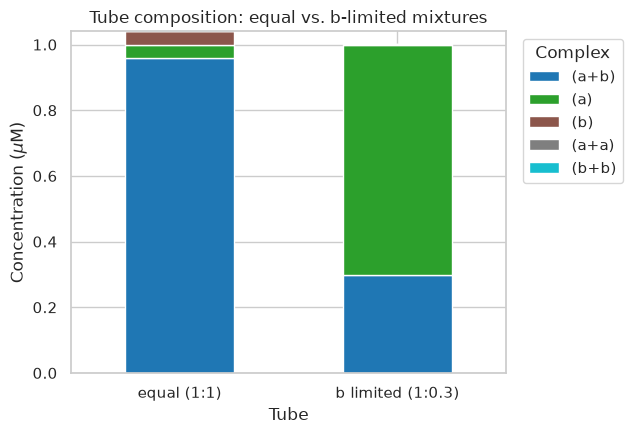

In [5]:
species = [(a, b), (a,), (b,), (a, a), (b, b)]
species_labels = ["(a+b)", "(a)", "(b)", "(a+a)", "(b+b)"]

def conc_series(conc_dict):
    return [find_conc(conc_dict, *s) / 1e-6 for s in species]

comp_df = pd.DataFrame(
    {
        "equal (1:1)": conc_series(conc_equal),
        "b limited (1:0.3)": conc_series(conc_blimited),
    },
    index=species_labels,
).T

fig, ax = plt.subplots(figsize=(6.5, 4.5))
comp_df.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_ylabel("Concentration ($\\mu$M)")
ax.set_xlabel("Tube")
ax.set_title("Tube composition: equal vs. b-limited mixtures")
ax.legend(title="Complex", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.setp(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
plt.show()


**Interpretation.** In the equal-concentration tube, the `(a+b)` duplex
dominates and the bar is almost entirely one color. In the `b`-limited tube,
the total height of the `(a+b)` bar drops to about 0.3 $\mu$M (all of the
available `b` is consumed, since $b$ is the limiting reagent and the duplex is
so favorable), while the leftover, unreacted `(a)` grows to fill most of the
remaining height. The homodimers stay negligible in both cases - too small to
even see on this scale.


## Worked example 2: competition from a third strand

Real designs often have more than two strand species, and an "off-target"
strand can compete with the intended partner for the same binding site. We
introduce a third strand `p2` that is *partially* complementary to `f`
(`f = a` from above) at both ends, and compare two versions: one where `p2`'s
mismatches make it a poor competitor, and one where it's a real competitor for
`f`.


In [6]:
f = Strand("GGGAAACCC", name="f")
p1 = Strand("GGGUUUCCC", name="p1")  # perfect complement of f (same as b above)

# p2_weak: mismatches scattered through the middle -> essentially no f binding
p2_weak = Strand("GGGCUACCC", name="p2_weak")
# p2_strong: only the two terminal bases mismatched -> still binds f appreciably
p2_strong = Strand("AGGUUUCCU", name="p2_strong")

def competition_tube(p2, name):
    return Tube(
        strands={f: 1e-6, p1: 1e-6, p2: 1e-6},
        complexes=SetSpec(max_size=2),
        name=name,
    )

tube_weak = competition_tube(p2_weak, "weak_competitor")
tube_strong = competition_tube(p2_strong, "strong_competitor")

result_comp = tube_analysis(tubes=[tube_weak, tube_strong], model=model, compute=["pfunc"])


In [7]:
def f_fate(result, tube, f, p1, p2):
    conc = result[tube].complex_concentrations
    return {
        "f free": find_conc(conc, f),
        "f+p1 (intended)": find_conc(conc, f, p1),
        "f+p2 (off-target)": find_conc(conc, f, p2),
    }

fate_weak = f_fate(result_comp, tube_weak, f, p1, p2_weak)
fate_strong = f_fate(result_comp, tube_strong, f, p1, p2_strong)

fate_df = pd.DataFrame({"weak competitor": fate_weak, "strong competitor": fate_strong}).T
display(fate_df / 1e-6)


,f free,f+p1 (intended),f+p2 (off-target)
weak competitor,0.040751,0.959217,0.000032
strong competitor,0.009111,0.842931,0.147958


*(The table above shows concentrations in units of 1 $\mu$M = total `f`, so
each row sums to $\approx 1$ and can be read directly as a fraction.)*


## Visualization: where does `f` end up?


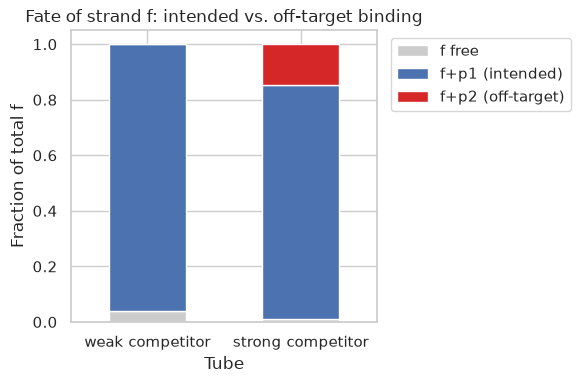

In [8]:
fate_frac = fate_df / 1e-6

fig, ax = plt.subplots(figsize=(6, 4))
fate_frac.plot(kind="bar", stacked=True, ax=ax, color=["#cccccc", "#4c72b0", "#d62728"])
ax.set_ylabel("Fraction of total f")
ax.set_xlabel("Tube")
ax.set_title("Fate of strand f: intended vs. off-target binding")
ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.setp(ax.get_xticklabels(), rotation=0)
fig.tight_layout()
plt.show()


**Interpretation.** With the weak competitor, `f` behaves almost exactly as
in worked example 1: essentially all of it ends up in `(f+p1)`, and `(f+p2)`
is negligible - `p2_weak`'s mismatches are enough to make it irrelevant. With
the strong competitor, roughly 15% of `f` is diverted into `(f+p2_strong)`,
*reducing* the yield of the intended `(f+p1)` duplex from $\approx 0.96$ to
$\approx 0.84$ - even though `p1` and `f` are still perfectly complementary
and nothing about their pairwise interaction changed. **Yield is a property
of the whole tube, not just of the intended pair.** This is the core idea
behind multi-strand design and orthogonality, which lessons 9-10 return to.


## Best practices and common pitfalls

- **`SetSpec(max_size=...)` grows combinatorially.** With $k$ distinct
  strands, `max_size=2` already considers $O(k^2)$ complexes (including
  homodimers); `max_size=3` is $O(k^3)$. Only include the strand multiplicity
  you actually need to model.
- **Concentrations are in molar units, and matter.** The same strands at 1 nM
  vs. 1 mM can have qualitatively different equilibria - a duplex that's
  >95% formed at 1 $\mu$M may be mostly dissociated at much lower
  concentrations. Always state concentrations explicitly when reporting
  yields.
- **Yield needs a denominator.** "The yield of `(a+b)`" is meaningless without
  specifying *relative to what* - relative to `a`, to `b`, or to whichever is
  limiting. With unequal concentrations these can differ substantially (here,
  99.8% vs. 29.9%).
- **A complex absent from `SetSpec` is invisible to the calculation.** If you
  forget to include a complex that would actually form (e.g. a 3-strand
  off-target), `tube_analysis` will simply never consider it - the
  concentrations you get back are only correct *within the set you specified*.


## Summary

In this notebook you:

1. Built `Tube` objects from strand/concentration dictionaries and a
   `SetSpec` controlling which complexes to consider.
2. Ran `tube_analysis` and read off equilibrium **complex concentrations**.
3. Defined and computed **yield** relative to a limiting strand, and saw how
   it depends on stoichiometry.
4. Saw how an unintended off-target interaction **redistributes**
   concentrations across the whole tube, reducing the yield of the intended
   complex even when that complex's own thermodynamics are unchanged.

**Next:** [`06_adv_tube_analysis.ipynb`](06_adv_tube_analysis.ipynb) sweeps
tube conditions - temperature, salt, and concentration - to build
melting-curve-style figures at the tube level.


## Exercises

1. In worked example 1b, what concentration of `b` would give a yield of
   `(a+b)` relative to `b` of exactly... well, it's already $\approx 0.998$.
   Try `b` at 1e-8 M (100x more dilute) instead - does the *relative* yield
   stay this high, or does dilution itself reduce it?
2. Add a fourth strand to worked example 2 that is a weak competitor for
   `p1` instead of `f` (i.e., partially complementary to `p1`). Does it
   reduce the yield of `(f+p1)`, and if so, by how much compared to the
   `p2_strong` case?
